# CellTypist - Bacteria dataset 
This CellTypist tutorial is applied on a Bacterie scRNA-seq dataset that consists of 2 celltypes: BF (biofilm cells) and P (Plaktonic)
We build an unsupervised learning model by applying PCA → neighbors → UMAP → Leiden clustering (unsupervised) → daarna CellTypist annotatie

## 1. Install CellTypist Package

In [3]:
!pip install celltypist


## 2. Import the libraries

In [4]:
import scanpy as sc #toolkit for single-cell analysis
import celltypist #automatic cell-annotation
from celltypist import models # to download specific models
import numpy as np #calculataions
import matplotlib.pyplot as plt #making some graphs

sc.settings.verbosity = 1  # Only show errors and warnings
sc.settings.set_figure_params(dpi=100, frameon=False) # Set figure quality to 100 dpi, no border

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 3. Load the bacteria data
This dataset contains Staphylococcus aureus bacteria in two distinct growth states: Biofilm (BF) and Planktonic (P). The aim of this study is to compare how these two populations differ in gene expression at the single-cell level. Biofilm cells are significantly harder to treat, as they are encased in a protective extracellular matrix that makes them highly resistant to antibiotics and the host immune system. Understanding the transcriptional differences between biofilm and planktonic cells is therefore critical for identifying potential therapeutic targets.

In [5]:
import h5py

# Fix: remove incompatible 'mask_var' field from the h5ad file
# This field was created by an older version of scanpy and causes 
# a loading error in newer versions. This only needs to be done once.
with h5py.File('BF_P_count_mat_clean.h5ad', 'a') as f:
    if 'mask_var' in f['uns']['pca']['params']:
        del f['uns']['pca']['params']['mask_var']

# Load the dataset
adata_bacteria = sc.read('BF_P_count_mat_clean.h5ad')


In [6]:
#look at the shape of the dataset,
adata_bacteria.shape

(7437, 2799)

In [7]:
# Show 5 BF and 5 P cells for comparison
import pandas as pd
bf_cells = adata_bacteria.obs[adata_bacteria.obs['Type_of_cells'] == 'BF'].head(5)
p_cells = adata_bacteria.obs[adata_bacteria.obs['Type_of_cells'] == 'P'].head(5)
print(pd.concat([bf_cells, p_cells]))

     non_ribo_counts Type_of_cells sample leiden
68         14.120000            BF     bf      0
96          8.600000            BF     bf      1
104        16.809999            BF     bf      5
107         8.700001            BF     bf      5
131         9.559999            BF     bf      6
1          38.130001             P      p      5
119        37.160004             P      p      1
158       113.260002             P      p      3
197        35.040001             P      p      3
247        66.379997             P      p      4


The table above displays a sample of 10 cells from the dataset, 5 Biofilm (BF) and 5 Planktonic (P). Each row represents a single bacterial cell, identified by its barcode. The **non_ribo_counts** column shows the *number of non-ribosomal RNA reads* captured per cell.
The **Type_of_cells** column indicates the *true growth state*,
and the **leiden** column shows the *unsupervised cluster* it was assigned to.
This confirms that both cell types are present and distinguishable in the dataset

## 4. Preprocessing (this step is not obliged)
Before proceeding with the analysis, we verify that the data has already been log1p-normalised to 10,000 counts per cell. By reversing the log1p transformation with np.expm1() and summing per cell, we confirm that all cells have exactly 10,000 counts — meaning normalisation was correctly applied prior to loading. No additional normalisation steps are therefore required.

In [8]:
counts_per_cell = np.expm1(adata_bacteria.X).sum(axis=1)  # Turn the log1p back to raw data
print('Counts per cell (min/max/average):')
print(f'  min:  {counts_per_cell.min():.1f}')
print(f'  max:  {counts_per_cell.max():.1f}')
print(f'  mean: {counts_per_cell.mean():.1f}')


Counts per cell (min/max/average):
  min:  10000.0
  max:  10000.0
  mean: 10000.0


#### Neighborhood graph
By building a neighborhood graph, we connect cells that are similar to each other based on their gene expression.

The first step is performing a PCA, which reduces the data to 40 principal components. Following the parameters of Korshoj & Kielian (2024), only the first 4 principal components are used to find the 9 most similar neighboring cells. Finally, UMAP reduces this graph to 2 dimensions for visualization, with min_dist=0.24 and spread=0.21 as specified in the paper.


In [9]:
# PCA, Build a neighborhood graph and calculate UMAP (for visualisation)
# Parameters based on the paper (Korshoj & Kielian, 2024)
sc.tl.pca(adata_bacteria, n_comps=40)                          # PCA
sc.pp.neighbors(adata_bacteria, n_neighbors=9, n_pcs=4)        # n_pcs=4 en n_neighbors=9 zoals paper
sc.tl.umap(adata_bacteria, min_dist=0.24, spread=0.21)         # UMAP params zoals paper

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5 & 6. Cell identity vs Leiden clustering

Before performing unsupervised clustering, we first visualise the two known cell types on the UMAP. 
Biofilm cells (BF, blue) are more broadly distributed across the UMAP space, reflecting their enhanced 
transcriptional heterogeneity, while Planktonic cells (P, orange) appear more concentrated.

The Leiden algorithm groups cells into clusters based on transcriptional similarity, without using any 
prior labels. Using a resolution of 0.15 — as specified in Korshoj & Kielian (2024) — the algorithm 
identifies 7 distinct subpopulations across the dataset. Each cluster potentially represents a unique 
transcriptional state within the Biofilm or Planktonic population.


(In this step, we compare the known biological labels (Biofilm vs Planktonic cells) with the structure revealed by unsupervised Leiden clustering. First, we visualize both cell identities on the UMAP to see how they distribute in the embedding. Then, we plot the Leiden clusters to examine whether the algorithm identifies similar groupings or reveals additional subpopulations. Finally, we quantify the percentage of BF and P cells within each Leiden cluster to assess how well the unsupervised clusters align with the expected biological categories.)

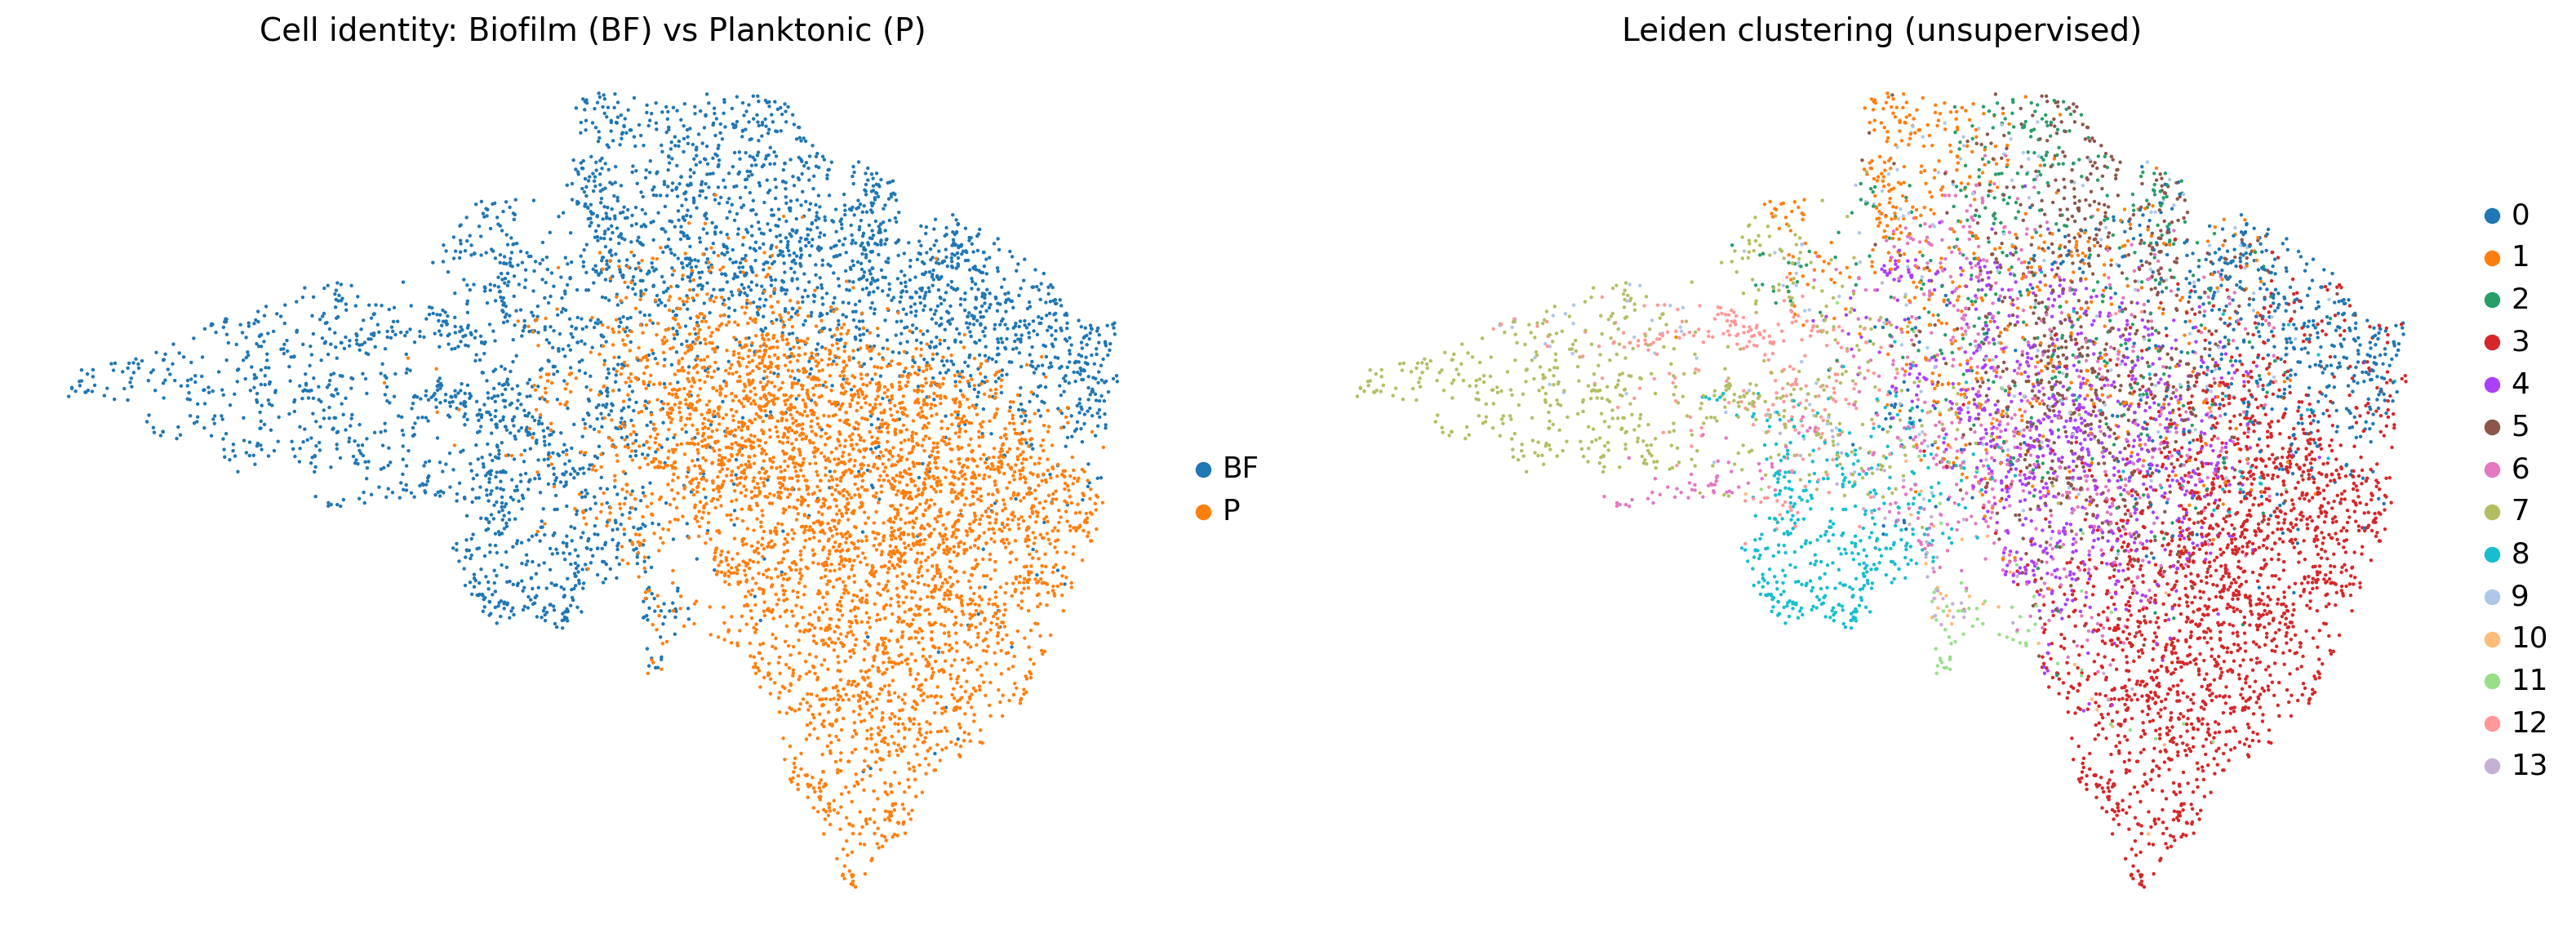

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Biofilm vs Planktonic
sc.pl.umap(
    adata_bacteria,
    color="Type_of_cells",
    size=10,
    title="Cell identity: Biofilm (BF) vs Planktonic (P)",
    ax=axes[0],
    show=False
)

# Plot 2: Leiden clusters (unsupervised)
sc.pl.umap(
    adata_bacteria,
    color="leiden",
    size=10,
    title="Leiden clustering (unsupervised)",
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()

In [11]:
# Check distribution of BF and P cells across each leiden cluster (like Figure 2D in paper)
import pandas as pd

distribution = pd.crosstab(
    adata_bacteria.obs['leiden'], 
    adata_bacteria.obs['Type_of_cells'],
    normalize='index'  # shows percentages per cluster
) * 100

print(distribution.round(1))

Type_of_cells    BF     P
leiden                   
0              76.6  23.4
1              65.0  35.0
2              67.0  33.0
3               8.2  91.8
4              25.2  74.8
5              41.5  58.5
6              50.0  50.0
7              89.3  10.7
8              85.5  14.5
9              72.7  27.3
10             46.9  53.1
11             33.8  66.2
12             90.2   9.8
13             48.9  51.1


## 7. Cluster Annotatie & Labeling
In this step, we assign biological interpretations to the seven Leiden clusters identified earlier. We first inspect which cluster IDs are present, then create a mapping that links each cluster to a descriptive subpopulation label. These labels are based on the marker‑gene profiles identified in the next step. After assigning the names to the dataset, we visualize the annotated subpopulations on the UMAP to evaluate whether the labels match the spatial structure of the data.

... storing 'subpopulation_names' as categorical


Gevonden clusters in Leiden: ['0', '1', '5', '6', '7', ..., '4', '10', '11', '12', '13']
Length: 14
Categories (14, object): ['0', '1', '2', '3', ..., '10', '11', '12', '13']


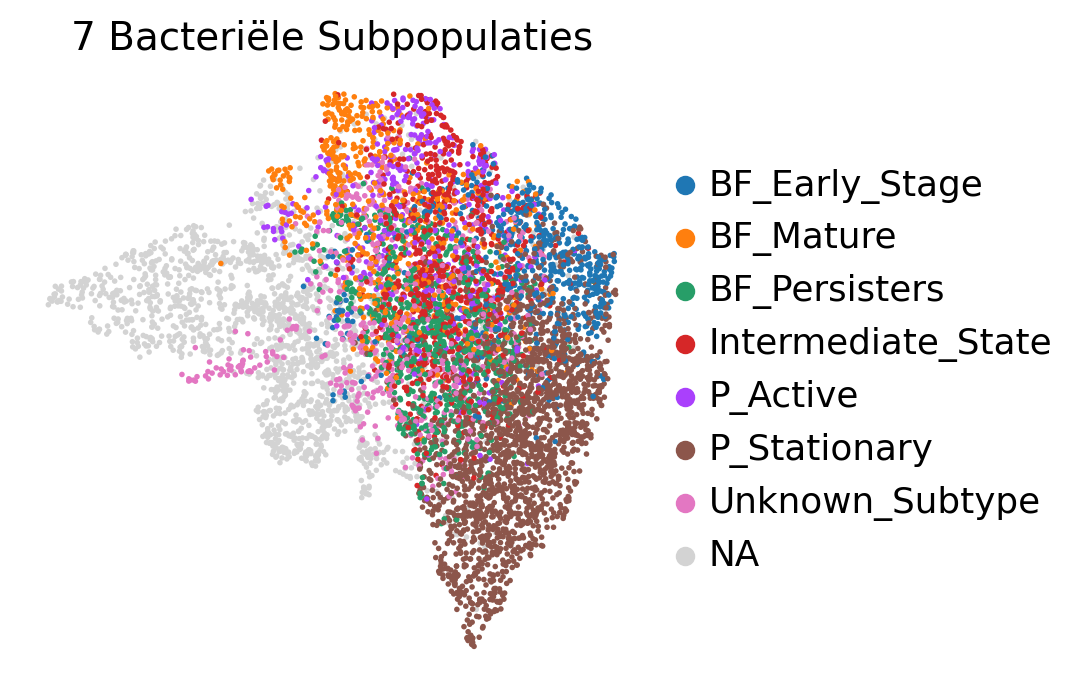

In [12]:
# --- Stap 7: Cluster Annotatie voor 7 Subpopulaties ---

# 1. Controleer eerst hoeveel clusters er exact zijn
print(f"Gevonden clusters in Leiden: {adata_bacteria.obs['leiden'].unique()}")

# 2. Maak een dictionary voor alle 7 clusters (0 t/m 6)
# TIP: Gebruik de resultaten van Stap 8 (Marker genen) om te bepalen 
# welke naam bij welk nummer hoort.
cluster_labels = {
    '0': 'BF_Early_Stage',
    '1': 'BF_Mature',
    '2': 'P_Active',
    '3': 'P_Stationary',
    '4': 'BF_Persisters',
    '5': 'Intermediate_State',
    '6': 'Unknown_Subtype'
}

# 3. Map de namen naar je data
adata_bacteria.obs['subpopulation_names'] = adata_bacteria.obs['leiden'].map(cluster_labels)

# 4. Visualiseer de 7 subpopulaties in de UMAP
sc.pl.umap(adata_bacteria, color='subpopulation_names', title='7 Bacteriële Subpopulaties', frameon=False)

## 8. Marker Gene Discovery (Differential Expression)
Here, we identify marker genes that characterize each Leiden cluster. Using a Wilcoxon rank‑sum test, we compute differentially expressed genes per cluster and visualize the top markers in a dotplot to compare expression strength and detection rate. We also extract the top 10 genes for each cluster in table form. These marker profiles are essential for determining the biological identity of each subpopulation and for validating the cluster annotations from the previous step.

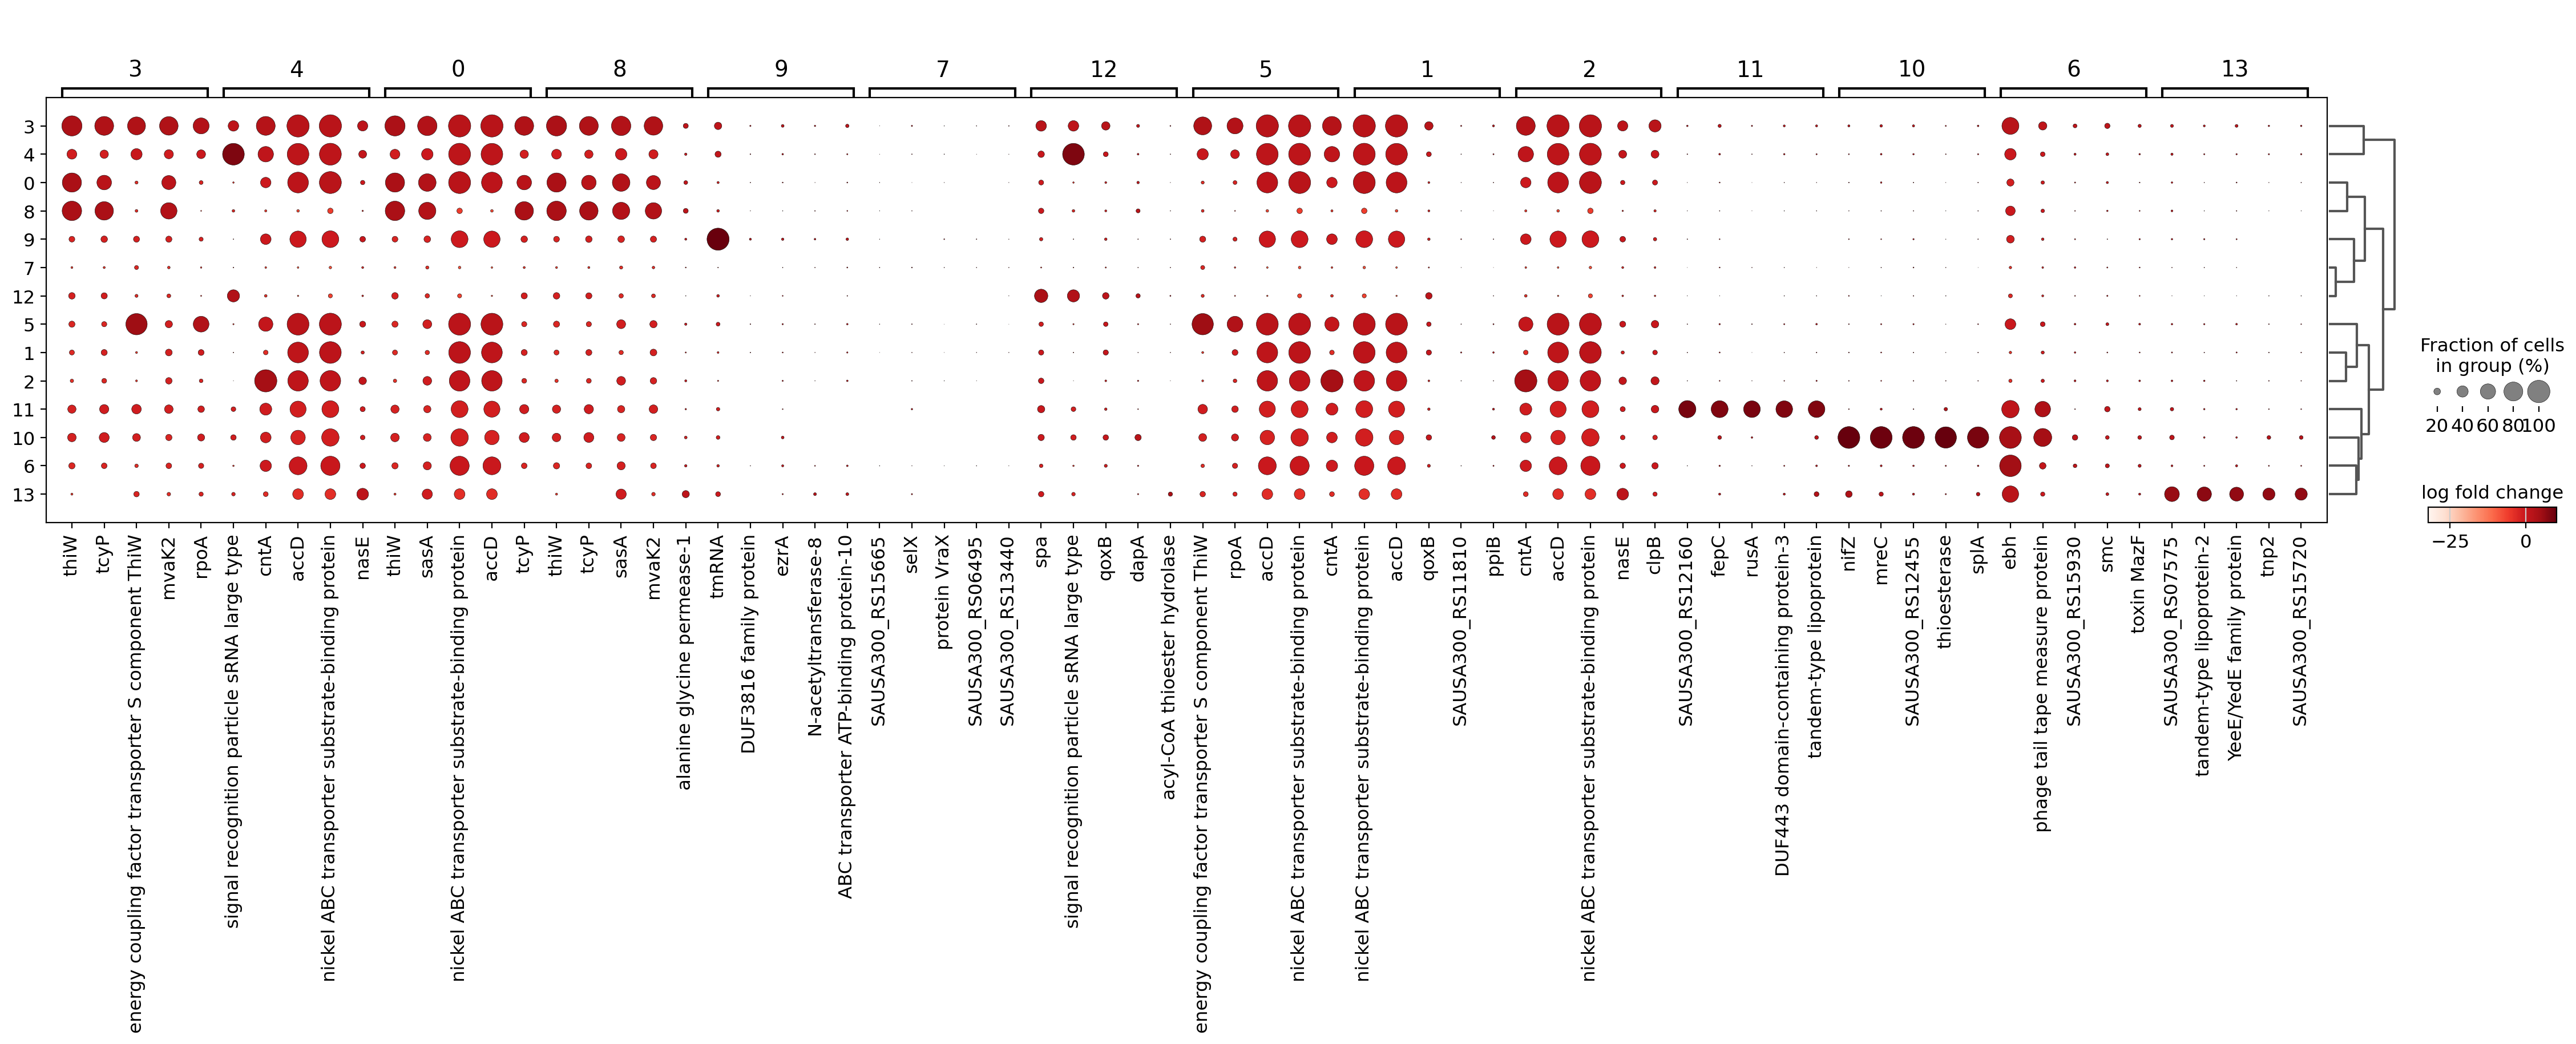

Top 10 marker genen per cluster:
                                                   0  \
0                                               thiW   
1                                               sasA   
2   nickel ABC transporter substrate-binding protein   
3                                               accD   
4                                               tcyP   
5                                              mvaK2   
6  bifunctional metallophosphatase/5'-nucleotidase-1   
7                                   SAUSA300_RS02370   
8                                               argG   
9                         alanine glycine permease-1   

                                                  1  \
0  nickel ABC transporter substrate-binding protein   
1                                              accD   
2                                              qoxB   
3                                  SAUSA300_RS11810   
4                                              ppiB   
5                   

In [13]:
# Bereken marker genen per cluster
sc.tl.rank_genes_groups(adata_bacteria, 'leiden', method='wilcoxon')

# Visualiseer de top 5 genen per cluster in een dotplot
sc.pl.rank_genes_groups_dotplot(adata_bacteria, n_genes=5, values_to_plot='logfoldchanges', min_logfoldchange=0.25)

# Toon de top 10 marker genen in tabelvorm
result = adata_bacteria.uns['rank_genes_groups']
groups = result['names'].dtype.names
markers_df = pd.DataFrame(
    {group: result['names'][group][:10] for group in groups}
)
print("Top 10 marker genen per cluster:")
print(markers_df)

## 9. Supervised Learning: Training the CellTypist Model
In this step, we train a supervised CellTypist model using the known cell labels in the dataset. After filtering out low‑abundance genes to improve model stability, the algorithm learns to associate transcriptional profiles with the Biofilm and Planktonic identities. The trained model is then saved for later use, allowing consistent and reproducible predictions across future analyses.

In [14]:
# Gebruik de 'Type_of_cells' labels om een nieuw model te trainen
# We filteren eerst genen die te weinig voorkomen voor een stabiel model
sc.pp.filter_genes(adata_bacteria, min_cells=3)

# Train het model (Supervised)
new_model = celltypist.train(adata_bacteria, labels = 'Type_of_cells', genes = adata_bacteria.var_names)

# Sla het model op voor later gebruik
new_model.write('bacteria_celltypist_model.pkl')
print("CellTypist model succesvol getraind en opgeslagen.")

🍳 Preparing data before training
🔬 Input data has 7437 cells and 2799 genes
⚖️ Scaling input data
🏋️ Training data using logistic regression
✅ Model training done!


CellTypist model succesvol getraind en opgeslagen.


## 10. Model Evaluation & Prediction
Here, we apply the trained CellTypist model to predict cell identities based on gene expression patterns. The predicted labels are added to the AnnData object and visualized alongside the true labels on the UMAP. This comparison allows us to evaluate how well the supervised model captures the biological structure of the dataset and whether the predictions align with the expected cell types.


🔬 Input data has 7437 cells and 2799 genes
🔗 Matching reference genes in the model
🧬 2799 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


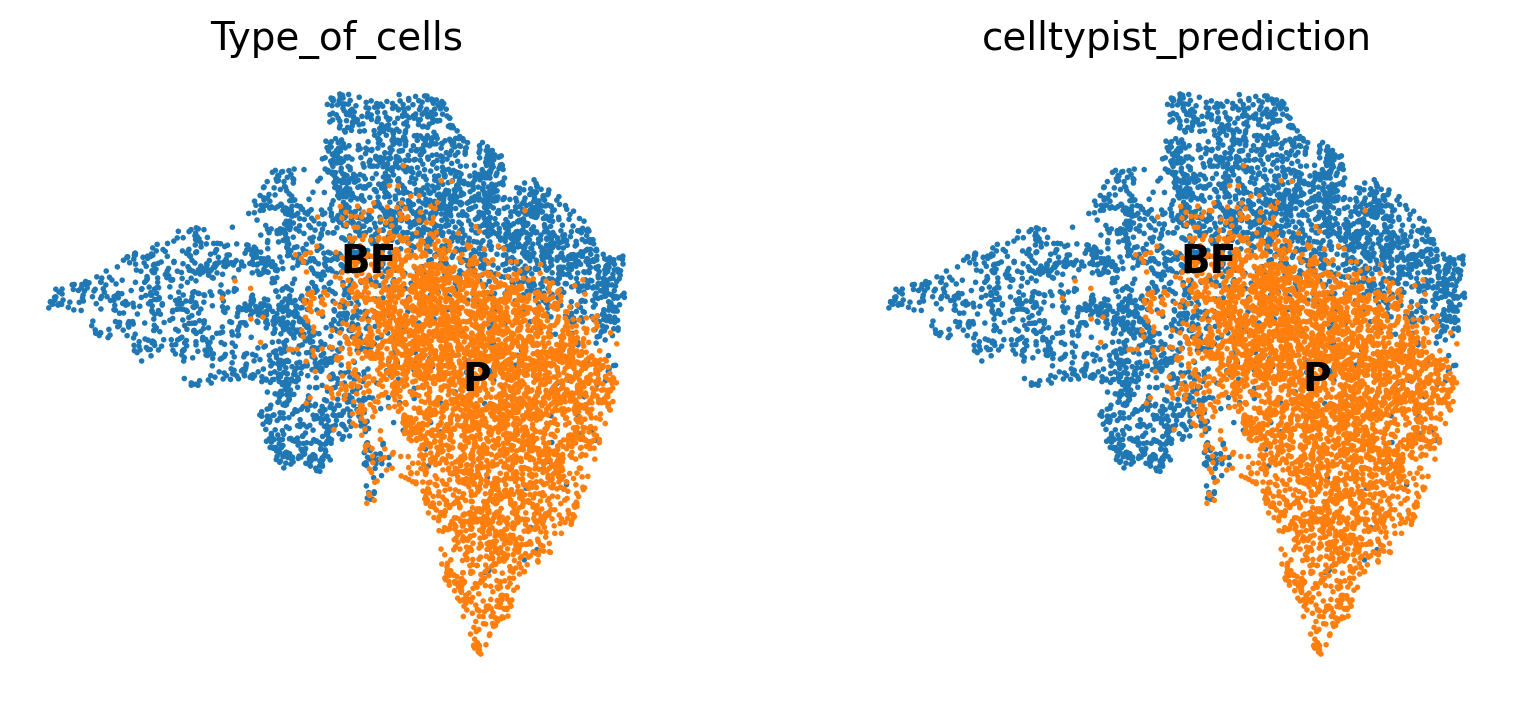

In [15]:
# Voer de predictie uit
predictions = celltypist.annotate(adata_bacteria, model = new_model, majority_voting = True)

# Voeg de voorspellingen toe aan het adata object
adata_bacteria.obs['celltypist_prediction'] = predictions.predicted_labels['predicted_labels']

# Vergelijk de voorspelling met de werkelijke labels in een UMAP
sc.pl.umap(adata_bacteria, color=['Type_of_cells', 'celltypist_prediction'], legend_loc='on data')

## 11. Functional Enrichment (Optional)